Load and Validate Data

In [1]:
from pathlib import Path
import json
from datasets import Dataset, Image

def load_dataset(base_path: str) -> Dataset:
    """Load dataset from raw files without caching"""
    data_path = Path(base_path)
    annotations_path = data_path / "recipes.json"
    images_dir = data_path / "images"

    with open(annotations_path) as f:
        examples = json.load(f)

    # Create dataset with direct image loading
    return Dataset.from_dict({
        "image": [str(images_dir / ex["image_id"]) for ex in examples],
        "title": [ex["title"] for ex in examples],
        "ingredients": [ex["ingredients"] for ex in examples],
        "instructions": [ex["instructions"] for ex in examples]
    }).cast_column("image", Image(decode=True))

# Usage
train_dataset = load_dataset("../data/mini_data")
val_dataset = load_dataset("../data/mini_data_val")
test_dataset = load_dataset("../data/mini_data_test")


In [2]:
# After loading datasets, add:
print("\nDataset structure sample:")
print(train_dataset[0])  # First example
print(f"\nTotal training examples: {len(train_dataset)}")
print(f"Total validation examples: {len(val_dataset)}")
print(f"Total test examples: {len(test_dataset)}")
print(f"Image type: {type(train_dataset[0]['image'])}")



Dataset structure sample:
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=280x168 at 0x1D39B93BA30>, 'title': 'Tomato Gratin with Lots of Cheese', 'ingredients': ['1 large tomatoes', '1/6 onion', '2 to 3 slices ham or bacon', '1 eggs', '1 tbsp mayonnaise', '1 easy melting cheese'], 'instructions': ['Slice the tomatoes in about 1 cm in width, then chop in half.', 'Layer on the bottom of a casserole dish.', 'Chop up the ham and onions.', 'Mix the egg and mayonnaise with a spoon.', 'When smooth, add the ham and onion and continue to mix.', 'Place the tomatoes in Step 1 on the mixture in Step 3, and add as much cheese as you like on top.', "Bake in the toaster oven for 7 minutes and it's done."]}

Total training examples: 19490
Total validation examples: 2110
Total test examples: 2055
Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>


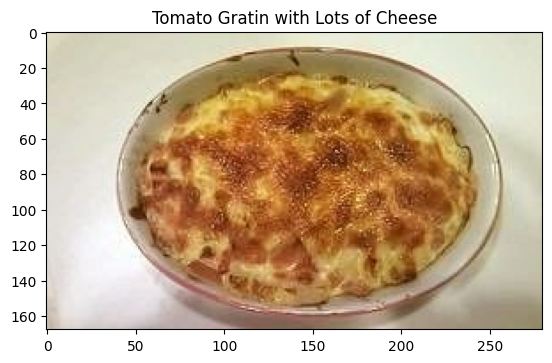

Ingredients: ['1 large tomatoes', '1/6 onion', '2 to 3 slices ham or bacon', '1 eggs', '1 tbsp mayonnaise', '1 easy melting cheese']
Instructions: 
 - Slice the tomatoes in about 1 cm in width, then chop in half.
 - Layer on the bottom of a casserole dish.
 - Chop up the ham and onions.
 - Mix the egg and mayonnaise with a spoon.
 - When smooth, add the ham and onion and continue to mix.
 - Place the tomatoes in Step 1 on the mixture in Step 3, and add as much cheese as you like on top.
 - Bake in the toaster oven for 7 minutes and it's done.


In [3]:
from matplotlib import pyplot as plt

def show_sample(idx: int):
    sample = train_dataset[idx]
    plt.imshow(sample["image"])
    plt.title(sample["title"][:50])
    plt.show()
    print("Ingredients:", sample["ingredients"])
    print("Instructions:", '\n -', '\n - '.join(sample["instructions"]))

show_sample(0)


Text Extraction for Evaluation

In [4]:
import re
import nltk
from nltk.translate import bleu_score, meteor_score
from pycocoevalcap.cider.cider import Cider
from sklearn.metrics import f1_score
nltk.download(['punkt', 'wordnet', 'omw-1.4'])

# def extract_components(text: str) -> dict:
#     return {
#         'title': re.search(r'**Recipe Title**: (.*?)\n', text).group(1).strip(),
#         'ingredients': re.findall(r'- (.*?)\n', text.split('**Ingredients**:')[1].split('**Instructions**:')[0]),
#         'instructions': [s.strip() for s in re.findall(r'\d+\. (.*?)(?=\n\d+\. |$)', text.split('**Instructions**:')[1])]
#     }
def extract_components(text: str) -> dict:
    """Improved parsing for generated recipe structure"""
    return {
        'title': re.search(r'\*\*Recipe Title\*\*: (.*?)\n', text).group(1).strip(),
        'ingredients': [ing.strip() for ing in
                       re.findall(r'- (.*?)(?=\n\s*\n|\Z)',
                                  text.split("**Ingredients**:")[1])], # double check
        'instructions': [step.strip() for step in
                        re.findall(r'\d+\. (.*?)(?=\n\d+\. |\Z)',
                                   text.split("**Instructions**:")[1])]
    }


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Me\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Me\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Me\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Prompt Engineering

In [5]:
from transformers import AutoTokenizer, BitsAndBytesConfig

tokenizer = AutoTokenizer.from_pretrained("google/gemma-3-4b-it")

def format_recipe(ex):
    prompt = f"""<start_of_turn>user
Generate a detailed recipe from this food image:
<start_of_image>
{ex['image']}
<end_of_turn>
<start_of_turn>model
**Recipe Title**: {ex['title']}

**Ingredients**:
""" + "\n".join(f"- {ingr}" for ingr in ex["ingredients"]) + """

**Instructions**:
""" + "\n".join(f"{i+1}. {step}" for i, step in enumerate(ex["instructions"]))  # Fixed line

    return {"text": prompt}



Metric Computation

In [7]:
def normalize_ingredient(ingredient: str) -> str:
    """Handle measurement variations and plurals"""
    return re.sub(r'\d+[\s\/]*\d*|tbsp|tsp|cups?|g|kg', '',
                 ingredient.lower()).strip()

def ingredient_f1(true_ings, pred_ings):
    """Enhanced F1-score with normalization"""
    true_set = {normalize_ingredient(i) for i in true_ings}
    pred_set = {normalize_ingredient(i) for i in pred_ings}

    tp = len(true_set & pred_set)
    fp = len(pred_set - true_set)
    fn = len(true_set - pred_set)

    precision = tp/(tp+fp) if (tp+fp) > 0 else 0
    recall = tp/(tp+fn) if (tp+fn) > 0 else 0
    return 2*(precision*recall)/(precision+recall) if (precision+recall) else 0

def calculate_rouge_l(reference, candidate):
    """ROUGE-L implementation for recipe steps"""
    rouge = Rouge()
    return rouge.get_scores(' '.join(candidate), ' '.join(reference))[0]['rouge-l']['f']

In [8]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    metrics = {
        'title_bleu': [],
        'ingredient_f1': [],
        'instructions_meteor': [],
        'instructions_rouge_l': [],
        'cider': []
    }

    cider_scorer = Cider()
    cider_scores = []

    for pred, ref in zip(decoded_preds, decoded_labels):
        pred_components = extract_components(pred)
        ref_components = extract_components(ref)

        # Title BLEU
        metrics['title_bleu'].append(
            bleu_score.sentence_bleu(
                [ref_components['title'].split()],
                pred_components['title'].split(),
                weights=(0.5, 0.5, 0, 0)
            )
        )

        # Ingredient F1
        metrics['ingredient_f1'].append(
            ingredient_f1(ref_components['ingredients'],
                         pred_components['ingredients'])
        )

        # Instruction Metrics
        ref_steps = ' '.join(ref_components['instructions'])
        pred_steps = ' '.join(pred_components['instructions'])

        metrics['instructions_meteor'].append(
            meteor_score.meteor_score([ref_steps.split()], pred_steps.split())
        )

        metrics['instructions_rouge_l'].append(
            calculate_rouge_l(ref_components['instructions'],
                             pred_components['instructions'])
        )

        # CIDEr (Requires specific format)
        cider_scores.append({
            'image_id': 0,  # Dummy ID for batch processing
            'caption': [pred_steps],
            'reference': [ref_steps]
        })

    # Aggregate CIDEr scores
    cider_score, _ = cider_scorer.compute_score(
        {i: [d['reference']] for i,d in enumerate(cider_scores)},
        {i: [d['caption']] for i,d in enumerate(cider_scores)}
    )
    metrics['cider'] = cider_score

    # Convert lists to averages
    return {k: sum(v)/len(v) if isinstance(v, list) else v
            for k,v in metrics.items()}


Model Configuration (watch out for GPU generation optimizations)

In [9]:
from transformers import AutoModelForImageTextToText, BitsAndBytesConfig
import torch
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer  # Replace TrainingArguments with SFTConfig


# 1. Quantization config: 4-bit NF4, bfloat16 compute, double quantization
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# 2. Device mapping: let transformers handle everything
device_map = "auto"

# 3. Attention implementation: use "eager" unless you have flash-attn installed
attn_impl = "eager"

# 4. Load the model
model = AutoModelForImageTextToText.from_pretrained(
    "google/gemma-3-4b-it",
    quantization_config=quantization_config,
    device_map=device_map,
    torch_dtype=torch.bfloat16,
    attn_implementation=attn_impl,
)

peft_config = LoraConfig(
    r=16,                  # LoRA rank (dimension of low-rank matrices)
    lora_alpha=32,         # Scaling factor (typically 2x rank)
    lora_dropout=0.05,     # Dropout probability for LoRA layers
    bias="none",           # Don't train bias parameters
    task_type="CAUSAL_LM", # Task type for causal language modeling
    target_modules="all-linear"  # Apply LoRA to all linear layers
)



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [10]:
print(model.hf_device_map)  # Verify all components assigned
print(torch.cuda.memory_summary())  # Should show <14GB allocated


{'': 0}
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   3102 MiB |   3196 MiB |  17177 MiB |  14075 MiB |
|       from large pool |   2977 MiB |   3071 MiB |  16995 MiB |  14018 MiB |
|       from small pool |    125 MiB |    125 MiB |    182 MiB |     57 MiB |
|---------------------------------------------------------------------------|
| Active memory         |   3102 MiB |   3196 MiB |  17177 MiB |  14075 MiB |
|       from large pool |   2977 MiB |   3071 MiB |  169

Training Setup

In [11]:
import peft
print(f"peft version: {peft.__version__}")  # Should show ≥0.11.0
from peft import LoraConfig
config = LoraConfig(r=8)
print(config)  # Should show LoraConfig object


peft version: 0.15.2
LoraConfig(task_type=None, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, base_model_name_or_path=None, revision=None, inference_mode=False, r=8, target_modules=None, exclude_modules=None, lora_alpha=8, lora_dropout=0.0, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, use_dora=False, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False)


In [12]:
from transformers import TrainingArguments
from trl import SFTTrainer

training_args = SFTConfig(
    output_dir="./recipe_generator",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    fp16=True,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,  # Must match eval_steps multiple
    dataset_text_field="text",  # Now valid in SFTConfig
    max_seq_length=2048,
)


trainer = SFTTrainer(
    model=model,
    args=training_args,  # Uses SFTConfig now
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    peft_config=peft_config,
    formatting_func=format_recipe,
    compute_metrics=compute_metrics,
)


Applying formatting function to train dataset:   0%|          | 0/19490 [00:00<?, ? examples/s]

Converting train dataset to ChatML:   0%|          | 0/19490 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/19490 [00:00<?, ? examples/s]

AttributeError: 'dict' object has no attribute 'endswith'

Image Processing

In [ ]:
from torchvision.transforms import Compose, Resize, ToTensor
from transformers import AutoProcessor


image_processor = AutoProcessor.from_pretrained("google/gemma-3-4b-it").image_processor

def preprocess_images(examples):
    images = [image.convert("RGB") for image in examples["image"]]
    processed = image_processor(
        images=images,
        return_tensors="pt",
        do_pan_and_scan=True,  # Better for high-res images
        size={"height": 896, "width": 896}
    )
    return {"pixel_values": processed.pixel_values}

# Apply preprocessing
train_dataset = train_dataset.map(preprocess_images, batched=True)
val_dataset = val_dataset.map(preprocess_images, batched=True)


Training Execution

In [ ]:
# Start training
trainer.train(resume_from_checkpoint=True,
             eval_dataset=val_dataset)

# Save final model
trainer.save_model("recipe_generator_final")


Inference Pipeline

In [ ]:
def generate_recipe(image_path: str) -> str:
    image = Image.open(image_path).convert("RGB")
    prompt = "<start_of_turn>user\nGenerate a detailed recipe from this food image:\n<start_of_image>"

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt",
        return_attention_mask=True
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2
    )

    return processor.decode(outputs[0], skip_special_tokens=True)


LLM Judge Frowns Upon You

In [ ]:
def llm_judge(recipe_text: str) -> list[float]:
    judge_prompt = f"""Rate this recipe (1-5) on:
- Clarity: Are instructions clear?
- Completeness: All necessary steps?
- Consistency: Logical flow?
- Practicality: Feasible to cook?
- Relevance: Matches dish goals?
- Allergen Safety: Allergen handling?

Recipe:
{recipe_text}

Scores (comma-separated):"""

    judge = pipeline("text-generation", model="Qwen/Qwen1.5-7B-Chat")
    response = judge(judge_prompt, max_new_tokens=50)[0]['generated_text']
    return [float(s) for s in re.findall(r'\d\.?\d*', response)[:6]]
